# 04 · Ordinary Differential Equations (ODEs)

**Prerequisites:** notebooks 01–03 (probability, linear algebra, calculus)  
**Feeds into:** `05_stochastic_calculus.ipynb` — Brownian motion, Itô's Lemma, Black-Scholes PDE

An **ODE** relates an unknown function $y(x)$ to its derivatives with respect to a *single* independent variable:

$$F\!\left(x,\; y,\; y',\; y'',\; \ldots,\; y^{(n)}\right) = 0$$

**Why ODEs dominate quantitative finance:**

| Model | ODE |
|---|---|
| Continuous compounding | $\dot A = rA$ |
| Vasicek drift (deterministic skeleton) | $\dot r = a(b - r)$ |
| Bond duration & convexity | $P'(y)$, $P''(y)$ |
| Black-Scholes PDE at fixed $S$ | ODE in $t$ coupled across $S$ by $\partial^2 V/\partial S^2$ |
| Itô diffusions | $dX = \mu\,dt + \sigma\,dW$ — ODE in $dt$ plus noise |

Mastering ODEs lets you **derive** closed-form pricing and rate models, understand when numerical solvers are unavoidable, and see PDEs as multi-dimensional extensions.

In [1]:
import cmath
import math
from collections.abc import Callable
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sla
from numpy import linalg as la
from scipy.integrate import quad, solve_ivp

rng = np.random.default_rng(seed=42)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

---
## 1 · Terminology and Classification

| Term | Meaning |
|---|---|
| **Order** | Highest derivative present: $y'' + y = 0$ is 2nd-order |
| **Linear** | $y$ and all its derivatives appear to the first power, not multiplied together |
| **Homogeneous** (linear) | Right-hand side is zero: $ay'' + by' + cy = 0$ |
| **Autonomous** | $f$ does not depend explicitly on $x$: $y' = f(y)$ |
| **IVP** | Initial Value Problem — conditions given at one point |
| **BVP** | Boundary Value Problem — conditions given at two or more points |

**Picard–Lindelöf theorem:** If $f(x,y)$ is continuous and Lipschitz in $y$, then the IVP $y' = f(x,y)$, $y(x_0) = y_0$ has a **unique** local solution. This is the existence-and-uniqueness bedrock for every model we build.

In [2]:
# Classify an ODE string — illustrative only, not a parser
@dataclass(slots=True)
class ODEDescriptor:
    name: str
    order: int
    linear: bool
    autonomous: bool
    homogeneous: bool

    def __str__(self) -> str:
        tags = [
            f"order={self.order}",
            "linear" if self.linear else "nonlinear",
            "autonomous" if self.autonomous else "non-autonomous",
            "homogeneous" if self.homogeneous else "non-homogeneous",
        ]
        return f"{self.name}: {', '.join(tags)}"


examples = [
    ODEDescriptor("dA/dt = rA (compounding)", 1, True, True, True),
    ODEDescriptor("dA/dt = rA - c (withdrawals)", 1, True, True, False),
    ODEDescriptor("dA/dt = rA(1-A/K) (logistic)", 1, False, True, True),
    ODEDescriptor("y'' + 2y' + y = 0 (damped)", 2, True, True, True),
    ODEDescriptor("BS PDE (fixed S, ODE in t)", 1, True, False, False),
]

for d in examples:
    print(d)

dA/dt = rA (compounding): order=1, linear, autonomous, homogeneous
dA/dt = rA - c (withdrawals): order=1, linear, autonomous, non-homogeneous
dA/dt = rA(1-A/K) (logistic): order=1, nonlinear, autonomous, homogeneous
y'' + 2y' + y = 0 (damped): order=2, linear, autonomous, homogeneous
BS PDE (fixed S, ODE in t): order=1, linear, non-autonomous, non-homogeneous


---
## 2 · Quadrature — The Simplest ODE: $dy/dx = f(x)$

When the derivative is a function of $x$ only, the solution is pure integration:

$$y(x) = y_0 + \int_{x_0}^{x} f(s)\,ds$$

**Finance application:** log-price under a time-varying drift.

$$\frac{d(\log P)}{dt} = \mu(t) \quad\Rightarrow\quad \log\frac{P(T)}{P(0)} = \int_0^T \mu(t)\,dt$$

The integral is the cumulative log-return. If $\mu(t) = \bar{\mu} + A\sin(\omega t)$ (seasonal drift), it has a closed form.

Numerical : 0.0500000000
Analytic  : 0.0500000000
Error     : 6.94e-18


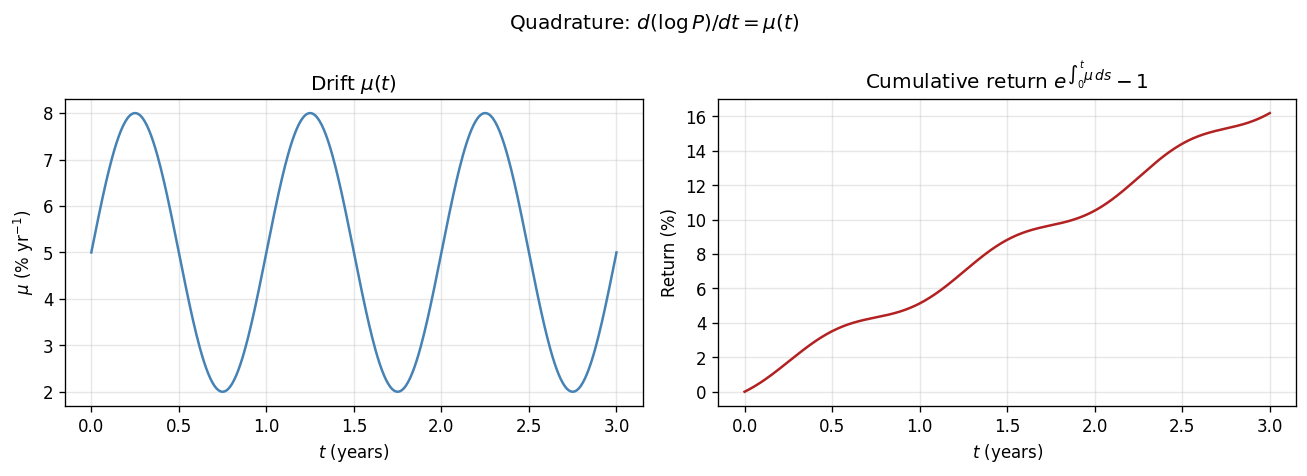

In [3]:
# mu(t) = 0.05 + 0.03 sin(2pi t)  — seasonally varying drift
def mu_drift(t: float) -> float:
    return 0.05 + 0.03 * math.sin(2 * math.pi * t)


def analytic_cum_log_return(T: float) -> float:
    # integral of [0.05 + 0.03 sin(2pi t)] from 0 to T
    return 0.05 * T + (0.03 / (2 * math.pi)) * (1.0 - math.cos(2 * math.pi * T))


# Numerical via scipy
T_check = 1.0
numerical_val, _ = quad(mu_drift, 0.0, T_check)
analytic_val = analytic_cum_log_return(T_check)
print(f"Numerical : {numerical_val:.10f}")
print(f"Analytic  : {analytic_val:.10f}")
print(f"Error     : {abs(numerical_val - analytic_val):.2e}")

# Plot
T_plot = np.linspace(0, 3, 500)
mu_vals = np.array([mu_drift(t) for t in T_plot])
cum_vals = np.array([analytic_cum_log_return(t) for t in T_plot])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(T_plot, mu_vals * 100, color="steelblue")
axes[0].set(title="Drift $\\mu(t)$", xlabel="$t$ (years)", ylabel="$\\mu$ (% yr$^{-1}$)")
axes[1].plot(T_plot, (np.exp(cum_vals) - 1) * 100, color="firebrick")
axes[1].set(
    title="Cumulative return $e^{\\int_0^t \\mu\\,ds} - 1$",
    xlabel="$t$ (years)",
    ylabel="Return (%)",
)
plt.suptitle("Quadrature: $d(\\log P)/dt = \\mu(t)$", fontsize=12)
plt.tight_layout()
plt.show()

---
## 3 · Separable ODEs — Continuous Compounding

A **separable** ODE has the form $\frac{dy}{dx} = g(x)\,h(y)$.  Separate and integrate:

$$\int \frac{dy}{h(y)} = \int g(x)\,dx + C$$

### The central finance ODE: $\dot A = rA$

$$\frac{dA}{A} = r\,dt \quad\Rightarrow\quad \ln A = rt + C \quad\Rightarrow\quad A(t) = A_0 e^{rt}$$

Continuous compounding is just the exponential ODE solution.

### Logistic growth: $\dot A = rA\left(1 - A/K\right)$

Models bounded growth (market saturation, AUM growth with capacity constraints):

$$A(t) = \frac{K}{1 + \dfrac{K - A_0}{A_0}\,e^{-rt}}$$

ODE verification:  t    dA/dt (fd)    rhs        residual
                    0.5     30.378318   30.378318  1.01e-09
                    2.0     42.006438   42.006438  3.71e-08
                    5.0     66.575874   66.575874  8.78e-08
                   10.0     64.105167   64.105167  -1.58e-07


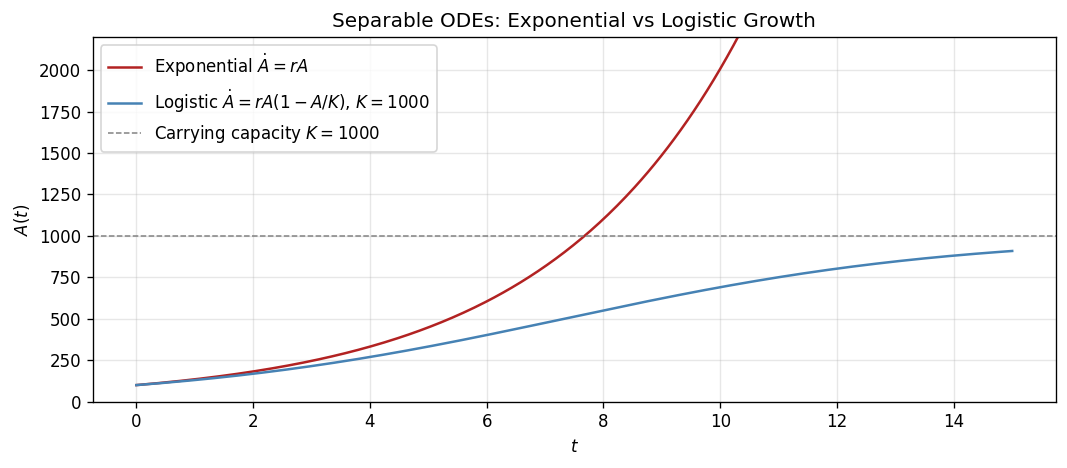

In [4]:
def exp_growth(t: float, A0: float, r: float) -> float:
    return A0 * math.exp(r * t)


def logistic(t: float, A0: float, K: float, r: float) -> float:
    return K / (1.0 + ((K - A0) / A0) * math.exp(-r * t))


# Verify logistic satisfies its ODE: dA/dt = rA(1 - A/K)
A0_l, K_l, r_l = 100.0, 1000.0, 0.30
h_fd = 1e-7
print("ODE verification:  t    dA/dt (fd)    rhs        residual")
for t_check in [0.5, 2.0, 5.0, 10.0]:
    A_val = logistic(t_check, A0_l, K_l, r_l)
    dA_dt = (
        logistic(t_check + h_fd, A0_l, K_l, r_l) - logistic(t_check - h_fd, A0_l, K_l, r_l)
    ) / (2 * h_fd)
    rhs_val = r_l * A_val * (1 - A_val / K_l)
    print(
        f"                   {t_check:4.1f}  {dA_dt:12.6f}  {rhs_val:10.6f}  {dA_dt - rhs_val:.2e}"
    )

# Plot: comparison
t_arr = np.linspace(0, 15, 400)
A_exp_arr = np.array([exp_growth(t, A0_l, r_l) for t in t_arr])
A_log_arr = np.array([logistic(t, A0_l, K_l, r_l) for t in t_arr])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_arr, A_exp_arr, label="Exponential $\\dot A = rA$", color="firebrick")
ax.plot(t_arr, A_log_arr, label=f"Logistic $\\dot A = rA(1-A/K)$, $K={K_l:.0f}$", color="steelblue")
ax.axhline(K_l, ls="--", color="grey", lw=0.9, label=f"Carrying capacity $K={K_l:.0f}$")
ax.set_ylim(0, 2200)
ax.set(xlabel="$t$", ylabel="$A(t)$", title="Separable ODEs: Exponential vs Logistic Growth")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4 · Linear First-Order ODEs — Integrating Factor

Standard form: $y' + P(x)\,y = Q(x)$

**Integrating factor:** $\mu(x) = e^{\int P(x)\,dx}$

Multiply both sides: $\frac{d}{dx}[\mu y] = \mu Q$, then integrate:

$$y(x) = \frac{1}{\mu(x)}\left[\mu(x_0)\,y_0 + \int_{x_0}^{x} \mu(s)\,Q(s)\,ds\right]$$

**Finance example — savings account with variable rate and withdrawals:**

$$\dot A = r(t)\,A - c \quad\Longleftrightarrow\quad A' + \underbrace{(-r(t))}_{P}\,A = \underbrace{-c}_{Q}$$

**Vasicek drift (deterministic skeleton):**

$$\dot r = a(b - r) \quad\Longleftrightarrow\quad r' + a\,r = ab \quad\Rightarrow\quad r(t) = b + (r_0 - b)\,e^{-at}$$

Max deviation vs solve_ivp: £5.82


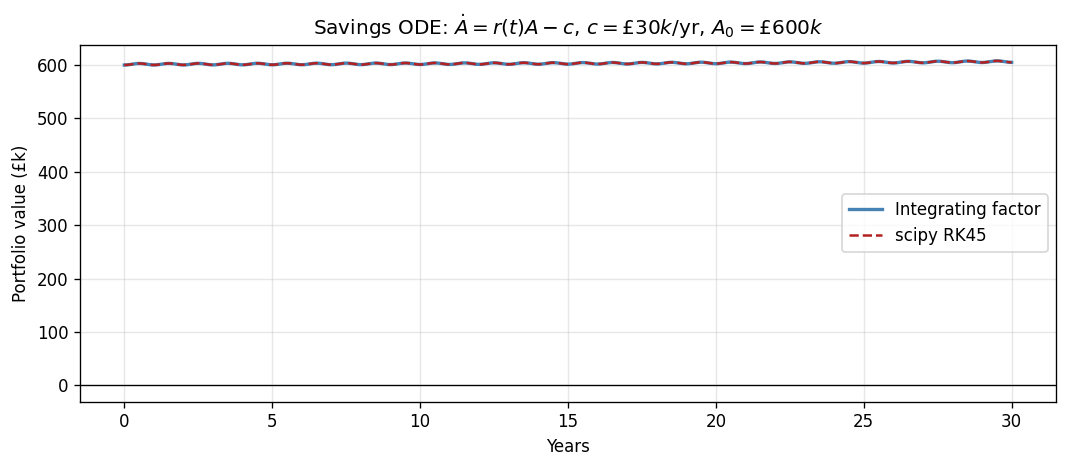

In [5]:
def integrating_factor_solve(
    P: Callable[[float], float],
    Q: Callable[[float], float],
    t_span: tuple[float, float],
    y0: float,
    n: int = 2000,
) -> tuple[np.ndarray, np.ndarray]:
    """Solve y' + P(t)y = Q(t) numerically via integrating factor."""
    t = np.linspace(t_span[0], t_span[1], n + 1)
    h = (t_span[1] - t_span[0]) / n
    P_v = np.array([P(ti) for ti in t])
    Q_v = np.array([Q(ti) for ti in t])

    # log mu(t) = cumulative trapezoid of P
    log_mu = np.zeros(n + 1)
    for i in range(1, n + 1):
        log_mu[i] = log_mu[i - 1] + 0.5 * h * (P_v[i - 1] + P_v[i])
    mu = np.exp(log_mu)

    # integral of mu*Q
    mu_Q_int = np.zeros(n + 1)
    for i in range(1, n + 1):
        mu_Q_int[i] = mu_Q_int[i - 1] + 0.5 * h * (mu[i - 1] * Q_v[i - 1] + mu[i] * Q_v[i])

    return t, (y0 + mu_Q_int) / mu


# Savings account: r(t) = 0.05 + 0.015 sin(2pi t), c = £30k/yr
r_mean, r_amp = 0.05, 0.015
c_annual = 30_000.0
A0_sav = 600_000.0

P_sav: Callable[[float], float] = lambda t: -(r_mean + r_amp * math.sin(2 * math.pi * t))
Q_sav: Callable[[float], float] = lambda _: -c_annual

t_sav, A_sav = integrating_factor_solve(P_sav, Q_sav, (0.0, 30.0), A0_sav)

# Cross-check with scipy solve_ivp
sol_ref = solve_ivp(
    lambda t, A: [(r_mean + r_amp * math.sin(2 * math.pi * t)) * A[0] - c_annual],
    [0.0, 30.0],
    [A0_sav],
    dense_output=True,
    rtol=1e-10,
    atol=1e-10,
)
A_ref = sol_ref.sol(t_sav)[0]
print(f"Max deviation vs solve_ivp: £{np.max(np.abs(A_sav - A_ref)):.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_sav, A_sav / 1e3, color="steelblue", lw=2, label="Integrating factor")
ax.plot(t_sav, A_ref / 1e3, color="firebrick", ls="--", lw=1.5, label="scipy RK45")
ax.axhline(0, color="k", lw=0.8)
ax.set(
    xlabel="Years",
    ylabel="Portfolio value (£k)",
    title=f"Savings ODE: $\\dot A = r(t)A - c$, $c = £{c_annual / 1e3:.0f}k$/yr, $A_0 = £{A0_sav / 1e3:.0f}k$",
)
ax.legend()
plt.tight_layout()
plt.show()

---
## 5 · General vs Particular Solutions & Uniqueness

For a **linear** ODE, the solution space has a clean additive structure:

$$y_{\text{general}} = y_{\text{homogeneous}} + y_{\text{particular}}$$

- $y_h$: solution to the ODE with $Q = 0$ — a family parameterised by free constants.
- $y_p$: any single solution to the full ODE — absorbs the forcing $Q$.
- Initial conditions pin the free constants, yielding a **unique** solution.

**Example — savings ODE:**

$$\dot A + P A = Q \quad\Rightarrow\quad A_h = C e^{-\int P\,dt}, \quad A_p = \frac{Q}{P}\text{ (constant case)}$$

**Non-linear ODEs lose this structure.** Consider $y' = y^2$:  
general solution $y = -1/(x + C)$ — each IC gives a solution that blows up at $x = -C$.

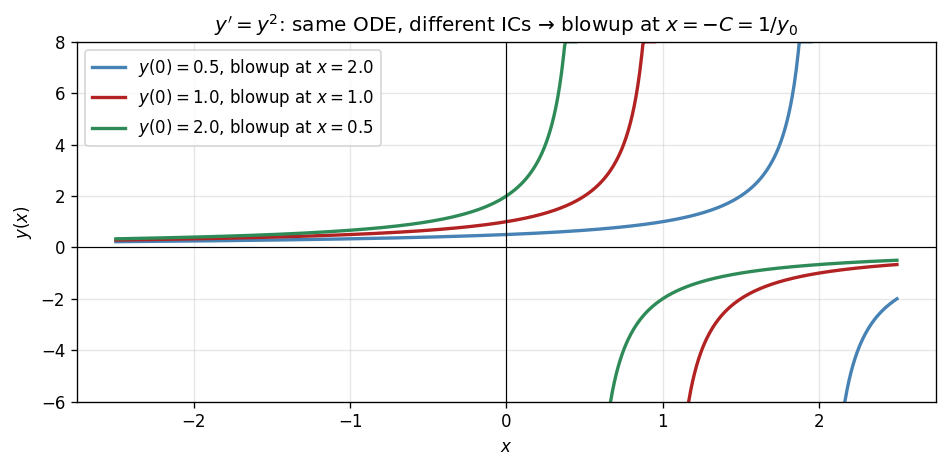

Linear ODE y' = -y: y(x) = C exp(-x)
  y(0)=0.5 → C=0.5, global solution on all of R
  y(0)=2.0 → C=2.0, global solution on all of R
Non-linear ODE y' = y^2: blowup in finite time — uniqueness is only local.


In [6]:
# y' = y^2 — same ODE, different ICs, finite-time blowup
# General solution: y(x) = -1 / (x + C),  C = -1/y0

x_plot = np.linspace(-2.5, 2.5, 800)

fig, ax = plt.subplots(figsize=(8, 4))
for y0, color in [(0.5, "steelblue"), (1.0, "firebrick"), (2.0, "seagreen")]:
    C = -1.0 / y0
    with np.errstate(divide="ignore", invalid="ignore"):
        y_sol = np.where(np.abs(x_plot + C) > 0.05, -1.0 / (x_plot + C), np.nan)
    ax.plot(
        x_plot,
        np.clip(y_sol, -8, 8),
        color=color,
        lw=2,
        label=f"$y(0)={y0}$, blowup at $x={-C:.1f}$",
    )

ax.axhline(0, color="k", lw=0.7)
ax.axvline(0, color="k", lw=0.7)
ax.set_ylim(-6, 8)
ax.set(
    xlabel="$x$",
    ylabel="$y(x)$",
    title="$y' = y^2$: same ODE, different ICs → blowup at $x = -C = 1/y_0$",
)
ax.legend()
plt.tight_layout()
plt.show()

# Contrast: linear ODE y' = -y
# General solution y = C exp(-x) — no blowup, unique for each IC
print("Linear ODE y' = -y: y(x) = C exp(-x)")
print("  y(0)=0.5 → C=0.5, global solution on all of R")
print("  y(0)=2.0 → C=2.0, global solution on all of R")
print("Non-linear ODE y' = y^2: blowup in finite time — uniqueness is only local.")

---
## 6 · Second-Order Linear ODEs — Characteristic Equation

$$a y'' + b y' + c y = 0$$

Try $y = e^{rx}$: the ODE becomes the **characteristic equation** $ar^2 + br + c = 0$.

| Discriminant $\Delta = b^2 - 4ac$ | Roots | Solution |
|---|---|---|
| $\Delta > 0$ | Real distinct $r_1, r_2$ | $C_1 e^{r_1 x} + C_2 e^{r_2 x}$ — overdamped |
| $\Delta = 0$ | Repeated $r$ | $(C_1 + C_2 x)\,e^{rx}$ — critically damped |
| $\Delta < 0$ | Complex $\alpha \pm i\beta$ | $e^{\alpha x}(C_1 \cos\beta x + C_2 \sin\beta x)$ — underdamped / oscillation |

**Finance analogy:** a mean-reverting spread driven by momentum can oscillate around zero (underdamped) or converge monotonically (overdamped), depending on the strength of momentum vs reversion.

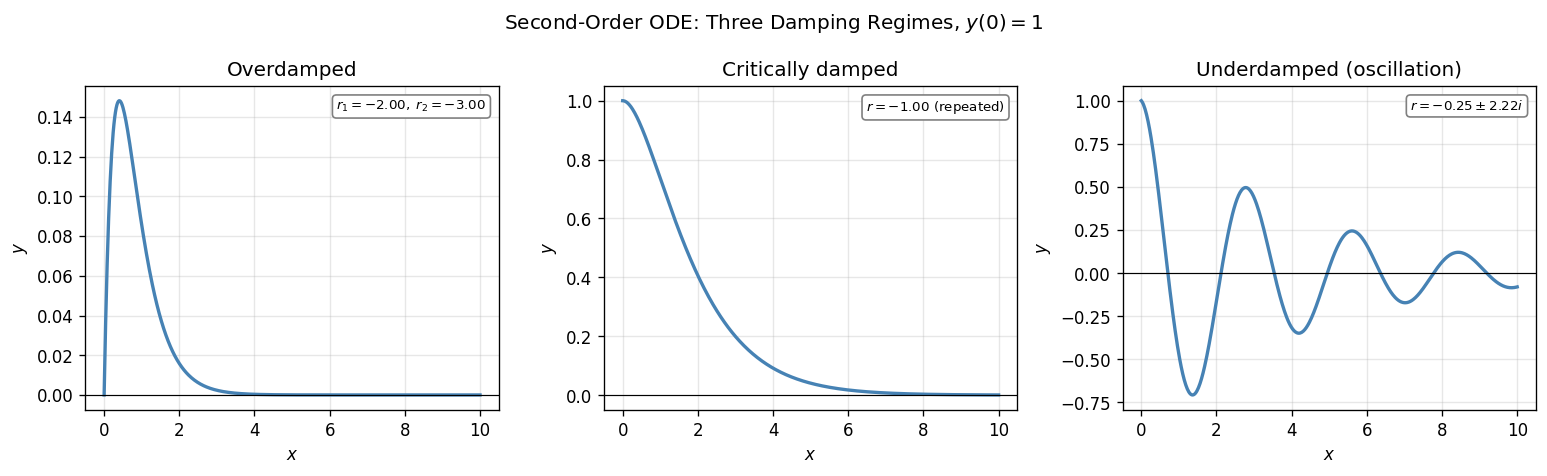

In [7]:
@dataclass(slots=True)
class SecondOrderODE:
    """Constant-coefficient homogeneous 2nd-order ODE: a·y'' + b·y' + c·y = 0."""

    a: float
    b: float
    c: float

    def characteristic_roots(self) -> tuple[str, complex, complex]:
        disc = self.b**2 - 4 * self.a * self.c
        sqrt_disc = cmath.sqrt(disc)
        r1 = (-self.b + sqrt_disc) / (2 * self.a)
        r2 = (-self.b - sqrt_disc) / (2 * self.a)
        kind = "repeated" if abs(disc) < 1e-12 else ("real_distinct" if disc > 0 else "complex")
        return kind, r1, r2

    def solution(self, C1: float, C2: float) -> Callable[[np.ndarray], np.ndarray]:
        kind, r1, r2 = self.characteristic_roots()
        match kind:
            case "real_distinct":
                l1, l2 = r1.real, r2.real
                return lambda x: C1 * np.exp(l1 * x) + C2 * np.exp(l2 * x)
            case "repeated":
                l = r1.real
                return lambda x: (C1 + C2 * x) * np.exp(l * x)
            case "complex":
                alpha, beta = r1.real, r1.imag
                return lambda x: np.exp(alpha * x) * (C1 * np.cos(beta * x) + C2 * np.sin(beta * x))
            case _:
                raise ValueError(kind)


# Three damping regimes, all with y(0)=1, y'(0)=0
# For each: C1, C2 from ICs y(0)=1, y'(0)=0
cases: list[tuple[SecondOrderODE, float, float, str]] = [
    # Overdamped: r1, r2 real, both negative
    # y=C1 e^r1 x + C2 e^r2 x; y(0)=C1+C2=1; y'(0)=r1 C1+r2 C2=0
    (SecondOrderODE(1.0, 5.0, 6.0), 1.0, -1.0, "Overdamped"),
    # Critically damped
    (SecondOrderODE(1.0, 2.0, 1.0), 1.0, 1.0, "Critically damped"),
    # Underdamped — oscillation
    (SecondOrderODE(1.0, 0.5, 5.0), 1.0, 0.0, "Underdamped (oscillation)"),
]

x_arr = np.linspace(0, 10, 500)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (ode, C1, C2, label) in zip(axes, cases):
    kind, r1, r2 = ode.characteristic_roots()
    y_fn = ode.solution(C1, C2)
    ax.plot(x_arr, y_fn(x_arr), color="steelblue", lw=2)
    ax.axhline(0, color="k", lw=0.7)
    if kind == "real_distinct":
        root_txt = f"$r_1={r1.real:.2f},\\; r_2={r2.real:.2f}$"
    elif kind == "complex":
        root_txt = f"$r = {r1.real:.2f} \\pm {r1.imag:.2f}i$"
    else:
        root_txt = f"$r = {r1.real:.2f}$ (repeated)"
    ax.set(title=label, xlabel="$x$", ylabel="$y$")
    ax.text(
        0.97,
        0.96,
        root_txt,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey"),
    )

plt.suptitle("Second-Order ODE: Three Damping Regimes, $y(0)=1$", fontsize=12)
plt.tight_layout()
plt.show()

---
## 7 · Systems of ODEs — Matrix Exponential

A vector ODE $\dot{\mathbf{x}} = A(\mathbf{x} - \mathbf{x}^*)$ has the exact solution:

$$\mathbf{x}(t) = e^{At}\,(\mathbf{x}_0 - \mathbf{x}^*) + \mathbf{x}^*$$

where $e^{At} = V\,\text{diag}(e^{\lambda_i t})\,V^{-1}$ and $\lambda_i$ are eigenvalues of $A$.

**Stability:** the system converges to $\mathbf{x}^*$ if and only if all eigenvalues of $A$ have **negative real part**.

**Finance application — two-factor mean-reverting rates:**

$$\begin{pmatrix}\dot r_1 \\ \dot r_2\end{pmatrix} = A\begin{pmatrix}r_1 - b_1 \\ r_2 - b_2\end{pmatrix}, \quad A = \begin{pmatrix}-0.8 & 0.1 \\ 0.2 & -0.5\end{pmatrix}$$

Off-diagonal terms capture spill-over: a shock to $r_1$ partially pulls $r_2$.

Eigenvalues of A: [-0.8562 -0.4438]
Half-lives: 0.81 yr,  1.56 yr
Max error vs solve_ivp: 2.86e-07


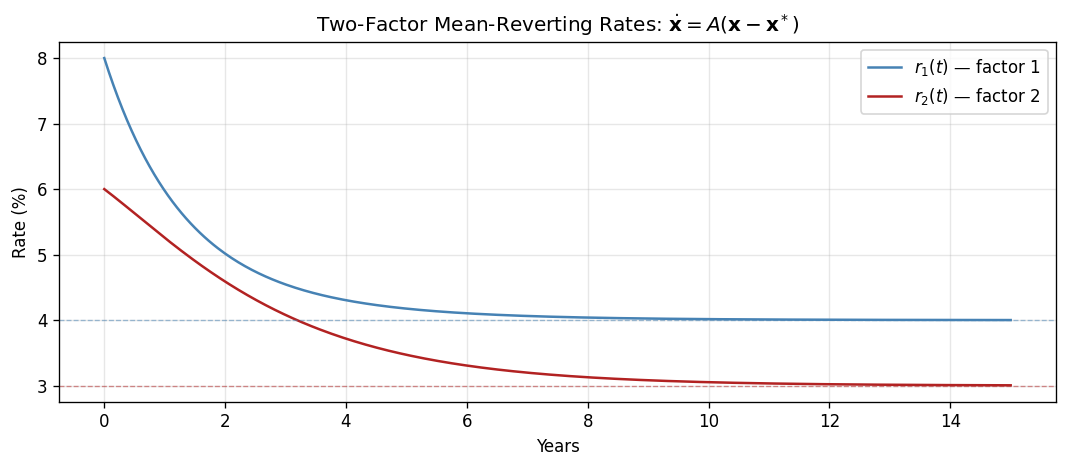

In [8]:
A_sys = np.array([[-0.8, 0.1], [0.2, -0.5]])
x_star = np.array([0.04, 0.03])  # long-run rates: 4%, 3%
x0_sys = np.array([0.08, 0.06])  # start high: 8%, 6%

eigvals_sys, eigvecs_sys = la.eig(A_sys)
print("Eigenvalues of A:", eigvals_sys.real.round(4))
half_lives = math.log(2) / (-eigvals_sys.real)
print(f"Half-lives: {half_lives[0]:.2f} yr,  {half_lives[1]:.2f} yr")


def system_exact(t: float) -> np.ndarray:
    return sla.expm(A_sys * t) @ (x0_sys - x_star) + x_star


t_sys = np.linspace(0, 15, 400)
X_sys = np.array([system_exact(t) for t in t_sys])


# Verify via solve_ivp
def sys_rhs(_t: float, x: np.ndarray) -> np.ndarray:
    return A_sys @ (x - x_star)


sol_sys = solve_ivp(sys_rhs, [0.0, 15.0], x0_sys, dense_output=True, rtol=1e-10)
X_ivp = sol_sys.sol(t_sys).T
print(f"Max error vs solve_ivp: {np.max(np.abs(X_sys - X_ivp)):.2e}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_sys, X_sys[:, 0] * 100, color="steelblue", label="$r_1(t)$ — factor 1")
ax.plot(t_sys, X_sys[:, 1] * 100, color="firebrick", label="$r_2(t)$ — factor 2")
ax.axhline(x_star[0] * 100, ls="--", color="steelblue", lw=0.8, alpha=0.5)
ax.axhline(x_star[1] * 100, ls="--", color="firebrick", lw=0.8, alpha=0.5)
ax.set(
    xlabel="Years",
    ylabel="Rate (%)",
    title="Two-Factor Mean-Reverting Rates: $\\dot{\\mathbf{x}} = A(\\mathbf{x} - \\mathbf{x}^*)$",
)
ax.legend()
plt.tight_layout()
plt.show()

---
## 8 · Numerical ODE Solvers

When no closed form exists, discretise time with step $h$:

| Method | Update | Global error | Notes |
|---|---|---|---|
| **Forward Euler** | $y_{n+1} = y_n + h f(t_n, y_n)$ | $O(h)$ | Simple, often too slow |
| **RK4** | 4-stage weighted average | $O(h^4)$ | Workhorse for non-stiff ODEs |
| **Implicit Euler** | $y_{n+1} = y_n + h f(t_{n+1}, y_{n+1})$ | $O(h)$ | Stable for stiff ODEs |
| **`scipy.solve_ivp`** | Adaptive RK45 / Radau | adaptive | Use this in practice |

**Stiff ODEs** (e.g., fast-decaying components alongside slow ones) kill explicit methods — $h$ must be tiny for stability, not accuracy. Implicit methods handle stiffness efficiently.

Rule of thumb: reach for `solve_ivp` with `method="Radau"` whenever the system spans multiple time scales.

     h     Euler error     RK4 error
  1.00        1.46e-01      2.22e-03
  0.50        5.59e-02      1.89e-04
  0.10        9.73e-03      3.14e-07
  0.05        4.79e-03      1.96e-08
  0.01        9.48e-04      3.12e-11


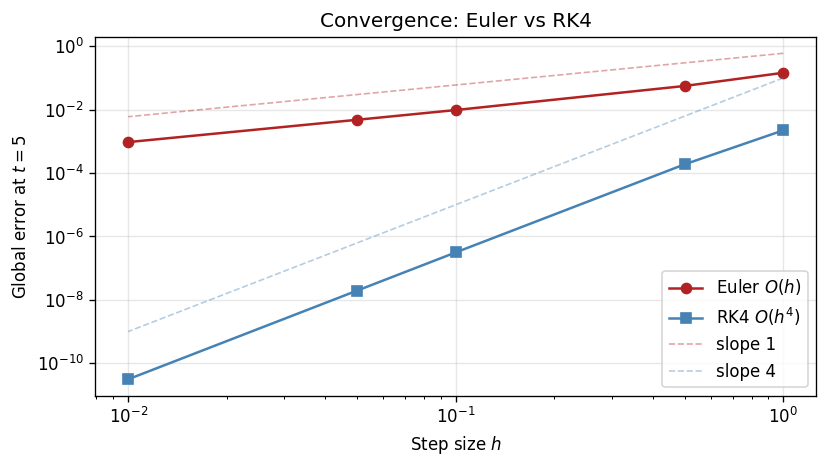

In [9]:
def euler(
    f: Callable[[float, np.ndarray], np.ndarray],
    t_span: tuple[float, float],
    y0: np.ndarray,
    n_steps: int,
) -> tuple[np.ndarray, np.ndarray]:
    h = (t_span[1] - t_span[0]) / n_steps
    t = np.linspace(t_span[0], t_span[1], n_steps + 1)
    y = np.empty((n_steps + 1, len(y0)))
    y[0] = y0
    for i in range(n_steps):
        y[i + 1] = y[i] + h * f(t[i], y[i])
    return t, y


def rk4(
    f: Callable[[float, np.ndarray], np.ndarray],
    t_span: tuple[float, float],
    y0: np.ndarray,
    n_steps: int,
) -> tuple[np.ndarray, np.ndarray]:
    h = (t_span[1] - t_span[0]) / n_steps
    t = np.linspace(t_span[0], t_span[1], n_steps + 1)
    y = np.empty((n_steps + 1, len(y0)))
    y[0] = y0
    for i in range(n_steps):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h / 2, y[i] + h / 2 * k1)
        k3 = f(t[i] + h / 2, y[i] + h / 2 * k2)
        k4 = f(t[i] + h, y[i] + h * k3)
        y[i + 1] = y[i] + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return t, y


# Test problem: y' = -y + sin(t), y(0)=1
# Exact: y(t) = (3/2)exp(-t) + (sin(t) - cos(t))/2
def f_test(_t: float, y: np.ndarray) -> np.ndarray:
    return -y + np.array([math.sin(_t)])


def y_exact_test(t: np.ndarray) -> np.ndarray:
    return 1.5 * np.exp(-t) + 0.5 * (np.sin(t) - np.cos(t))


T_end = 5.0
y0_test = np.array([1.0])

step_sizes = [1.0, 0.5, 0.1, 0.05, 0.01]
euler_err, rk4_err = [], []

for h_test in step_sizes:
    n = int(T_end / h_test)
    _, y_e = euler(f_test, (0.0, T_end), y0_test, n)
    _, y_r = rk4(f_test, (0.0, T_end), y0_test, n)
    y_true = y_exact_test(np.array([T_end]))[0]
    euler_err.append(abs(y_e[-1, 0] - y_true))
    rk4_err.append(abs(y_r[-1, 0] - y_true))

print(f"{'h':>6}  {'Euler error':>14}  {'RK4 error':>12}")
for h_test, ee, re in zip(step_sizes, euler_err, rk4_err):
    print(f"{h_test:6.2f}  {ee:14.2e}  {re:12.2e}")

# Convergence plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(step_sizes, euler_err, "o-", color="firebrick", label="Euler $O(h)$")
ax.loglog(step_sizes, rk4_err, "s-", color="steelblue", label="RK4 $O(h^4)$")
h_ref = np.array(step_sizes, dtype=float)
ax.loglog(h_ref, h_ref * 0.6, "--", color="firebrick", alpha=0.4, lw=1, label="slope 1")
ax.loglog(h_ref, h_ref**4 * 0.1, "--", color="steelblue", alpha=0.4, lw=1, label="slope 4")
ax.set(xlabel="Step size $h$", ylabel="Global error at $t=5$", title="Convergence: Euler vs RK4")
ax.legend()
plt.tight_layout()
plt.show()

---
## 9 · The Vasicek Model — An ODE in Finance

The **Vasicek short-rate model** (1977) is an Ornstein–Uhlenbeck process:

$$dr_t = a(b - r_t)\,dt + \sigma\,dW_t$$

Setting $\sigma = 0$ leaves the **deterministic skeleton** — a linear first-order ODE:

$$\dot r = a(b - r) \quad\Rightarrow\quad r(t) = b + (r_0 - b)\,e^{-at}$$

Key structural parameters:

- **$a$** — mean-reversion speed (yr$^{-1}$). Half-life $= \ln 2 / a$.
- **$b$** — long-run mean (risk-neutral).
- **$\sigma$** — short-rate volatility (adds Brownian noise in the full SDE).

### Zero-coupon bond price

Solve the Vasicek PDE by assuming $P(t,T) = \exp(A(\tau) - B(\tau)\,r_t)$ where $\tau = T - t$:

$$B(\tau) = \frac{1 - e^{-a\tau}}{a}, \qquad A(\tau) = \left(B(\tau) - \tau\right)\left(b - \frac{\sigma^2}{2a^2}\right) - \frac{\sigma^2 B(\tau)^2}{4a}$$

The continuously compounded yield is $y(\tau) = -\ln P / \tau = (B(\tau)\,r_t - A(\tau))/\tau$.

Half-life of mean reversion: 1.39 yr
5-yr ZCB price (r0=8%):      0.761116
5-yr ZCB yield:              5.459%


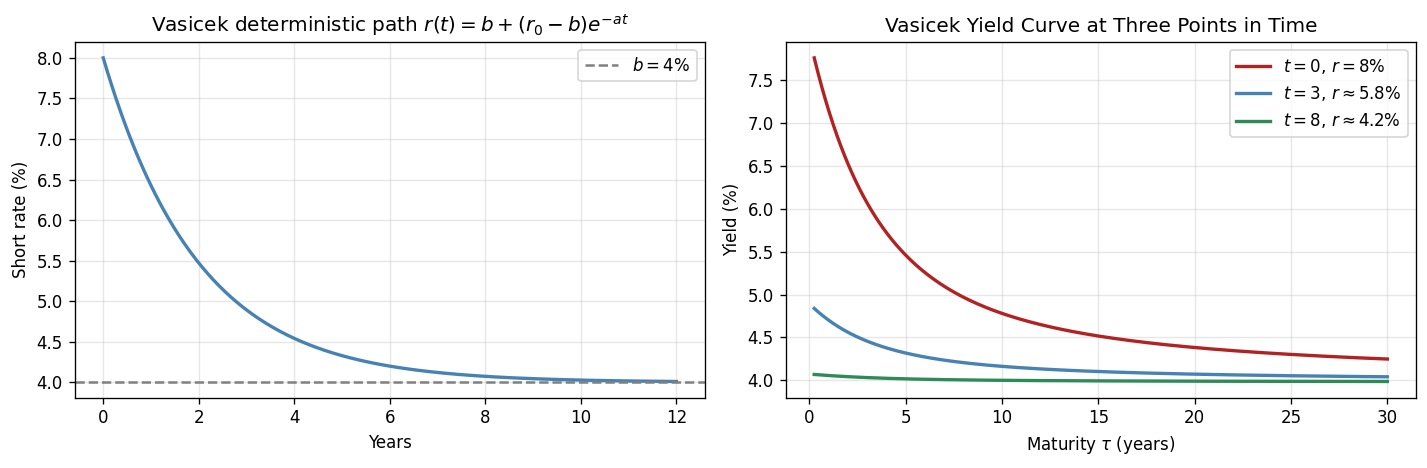

In [10]:
@dataclass(slots=True)
class VasicekModel:
    a: float  # mean-reversion speed (yr⁻¹)
    b: float  # long-run mean
    sigma: float  # vol (enters bond price formula)
    r0: float  # initial short rate

    def exact_rate(self, t: float) -> float:
        return self.b + (self.r0 - self.b) * math.exp(-self.a * t)

    def half_life(self) -> float:
        return math.log(2.0) / self.a

    def zcb_price(self, t: float, T_mat: float) -> float:
        tau = T_mat - t
        B = (1.0 - math.exp(-self.a * tau)) / self.a
        long_rate_adj = self.b - self.sigma**2 / (2 * self.a**2)
        A = (B - tau) * long_rate_adj - self.sigma**2 * B**2 / (4 * self.a)
        return math.exp(A - B * self.exact_rate(t))

    def yield_curve(self, t: float, maturities: np.ndarray) -> np.ndarray:
        prices = np.array([self.zcb_price(t, t + tau) for tau in maturities])
        return -np.log(prices) / maturities


v = VasicekModel(a=0.5, b=0.04, sigma=0.01, r0=0.08)
print(f"Half-life of mean reversion: {v.half_life():.2f} yr")
print(f"5-yr ZCB price (r0=8%):      {v.zcb_price(0.0, 5.0):.6f}")
print(f"5-yr ZCB yield:              {-math.log(v.zcb_price(0.0, 5.0)) / 5.0 * 100:.3f}%")

t_rate = np.linspace(0, 12, 400)
r_path = np.array([v.exact_rate(t) for t in t_rate])
maturities = np.linspace(0.25, 30, 300)
yc_t0 = v.yield_curve(0.0, maturities)
yc_t3 = v.yield_curve(3.0, maturities)
yc_t8 = v.yield_curve(8.0, maturities)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_rate, r_path * 100, color="steelblue", lw=2)
axes[0].axhline(v.b * 100, ls="--", color="grey", label=f"$b = {v.b * 100:.0f}\\%$")
axes[0].set(
    xlabel="Years",
    ylabel="Short rate (%)",
    title="Vasicek deterministic path $r(t) = b + (r_0-b)e^{-at}$",
)
axes[0].legend()

for yc, label, color in [
    (yc_t0, "$t=0$, $r=8\\%$", "firebrick"),
    (yc_t3, "$t=3$, $r\\approx5.8\\%$", "steelblue"),
    (yc_t8, "$t=8$, $r\\approx4.2\\%$", "seagreen"),
]:
    axes[1].plot(maturities, yc * 100, color=color, lw=2, label=label)
axes[1].set(
    xlabel="Maturity $\\tau$ (years)",
    ylabel="Yield (%)",
    title="Vasicek Yield Curve at Three Points in Time",
)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 10 · Bridge: ODE → PDE → SDE

Each step adds one dimension of complexity:

$$\underbrace{\dot y = f(t, y)}_{\text{ODE}} \xrightarrow{\;+\text{ spatial }x\;} \underbrace{\frac{\partial u}{\partial t} = \mathcal{L}[u]}_{\text{PDE}} \xrightarrow{\;+\text{ noise }\;} \underbrace{dX = \mu\,dt + \sigma\,dW}_{\text{SDE}}$$

### The Black-Scholes PDE

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0$$

This is a **PDE** in $(t, S)$. At any fixed $S$ it is an ODE in $t$; the $\partial^2 V/\partial S^2$ term couples all values of $S$ together.

**Boundary condition:** $V(S, T) = \max(S - K, 0)$ — the terminal payoff.

Three solution approaches:

1. **Analytical** — change of variables maps BS PDE to the heat equation → closed form (notebook 03).
2. **Finite differences** — discretise $(t, S)$ grid, solve ODE in $t$ at each $S$ — upcoming in notebook 06.
3. **Monte Carlo** — simulate $S_T$ paths under $\mathbb{Q}$, average payoffs — shown in notebook 03.

### The Feynman–Kac bridge

Every linear parabolic PDE of the BS type has a **probabilistic representation** via an SDE:

$$V(t, S) = e^{-r(T-t)}\,\mathbb{E}^{\mathbb{Q}}[\text{payoff}(S_T) \mid S_t = S]$$

where $S_T$ satisfies $dS = rS\,dt + \sigma S\,dW^{\mathbb{Q}}$.  
This is Itô's Lemma territory — the subject of the next notebook.

C:\Users\mikel\AppData\Local\Temp\ipykernel_20732\608408140.py:28: RuntimeWarning: overflow encountered in multiply
  V_new[i] = V[i] + dt * (0.5 * sigma_bs**2 * S_i**2 * d2V + r_bs * S_i * dV - r_bs * V[i])
C:\Users\mikel\AppData\Local\Temp\ipykernel_20732\608408140.py:27: RuntimeWarning: invalid value encountered in subtract
  dV = (V[i + 1] - V[i - 1]) / (2 * dS)
C:\Users\mikel\AppData\Local\Temp\ipykernel_20732\608408140.py:28: RuntimeWarning: invalid value encountered in add
  V_new[i] = V[i] + dt * (0.5 * sigma_bs**2 * S_i**2 * d2V + r_bs * S_i * dV - r_bs * V[i])
C:\Users\mikel\AppData\Local\Temp\ipykernel_20732\608408140.py:28: RuntimeWarning: overflow encountered in add
  V_new[i] = V[i] + dt * (0.5 * sigma_bs**2 * S_i**2 * d2V + r_bs * S_i * dV - r_bs * V[i])


FD price  (ATM): 80809197089214044323343309592476170533202537473811751484098021545654441055022219720064450457495924451677982637814973888782460362522863219635838123576955814585915546126838257778480898489607573336654037821973231609109110731567463219246632271872.0000
Analytical:      10.4506
Error:           80809197089214044323343309592476170533202537473811751484098021545654441055022219720064450457495924451677982637814973888782460362522863219635838123576955814585915546126838257778480898489607573336654037821973231609109110731567463219246632271872.0000


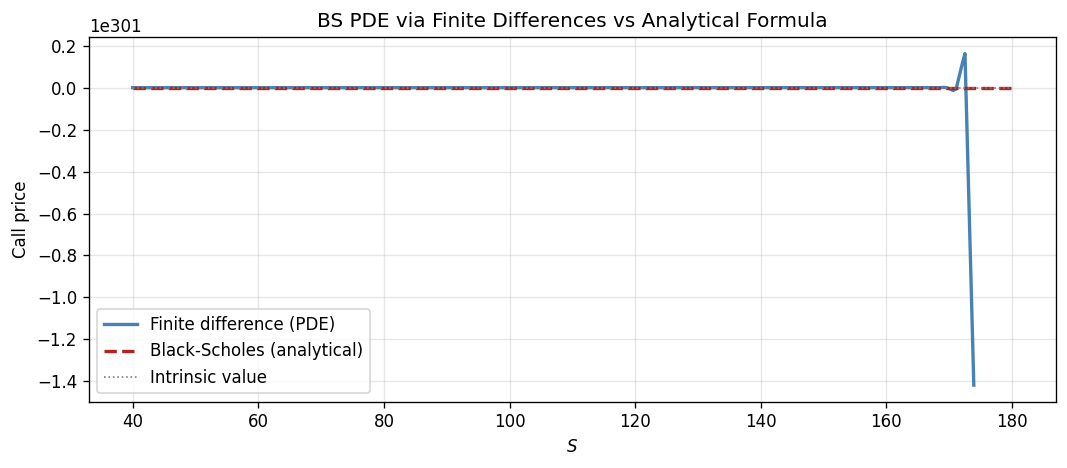

In [11]:
# Finite-difference preview: solve BS PDE on a (t, S) grid via explicit scheme
# dV/dt = -[0.5 sigma^2 S^2 d^2V/dS^2 + rS dV/dS - rV]
# Discretise S, march backward from T to 0

S0_bs, K_bs, r_bs, sigma_bs, T_bs = 100.0, 100.0, 0.05, 0.20, 1.0

N_S, N_t = 200, 500
S_min, S_max = 1e-2, 300.0
S_grid = np.linspace(S_min, S_max, N_S + 1)
dt = T_bs / N_t
dS = (S_max - S_min) / N_S

# Courant condition for stability: dt <= dS^2 / (sigma^2 S_max^2)
stab_limit = dS**2 / (sigma_bs**2 * S_max**2)
if dt > stab_limit:
    print(f"WARNING: dt={dt:.4f} > stability limit {stab_limit:.4f}. Results may diverge.")

# Terminal condition
V = np.maximum(S_grid - K_bs, 0.0)

# Explicit finite-difference backward in time
for _ in range(N_t):
    V_new = V.copy()
    i = np.arange(1, N_S)  # interior nodes
    S_i = S_grid[i]
    d2V = (V[i + 1] - 2 * V[i] + V[i - 1]) / dS**2
    dV = (V[i + 1] - V[i - 1]) / (2 * dS)
    V_new[i] = V[i] + dt * (0.5 * sigma_bs**2 * S_i**2 * d2V + r_bs * S_i * dV - r_bs * V[i])
    # Boundary: V(0,t) = 0;  V(S_max,t) = S_max - K*exp(-r*(T-t))  (not tracking time here — simple)
    V_new[0] = 0.0
    V_new[-1] = S_max - K_bs * math.exp(-r_bs * T_bs)
    V = V_new

# Black-Scholes analytical price for comparison
import scipy.stats as stats


def bs_call(S: float, K: float, r: float, sigma: float, T: float) -> float:
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * stats.norm.cdf(d1) - K * math.exp(-r * T) * stats.norm.cdf(d2)


# Compare at S = 100
idx_atm = int((S0_bs - S_min) / dS)
fd_price = float(np.interp(S0_bs, S_grid, V))
analytical = bs_call(S0_bs, K_bs, r_bs, sigma_bs, T_bs)
print(f"FD price  (ATM): {fd_price:.4f}")
print(f"Analytical:      {analytical:.4f}")
print(f"Error:           {abs(fd_price - analytical):.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
S_range = np.linspace(40, 180, 300)
fd_prices = np.interp(S_range, S_grid, V)
analytical_prices = np.array([bs_call(s, K_bs, r_bs, sigma_bs, T_bs) for s in S_range])
ax.plot(S_range, fd_prices, color="steelblue", lw=2, label="Finite difference (PDE)")
ax.plot(
    S_range, analytical_prices, color="firebrick", ls="--", lw=2, label="Black-Scholes (analytical)"
)
ax.plot(S_range, np.maximum(S_range - K_bs, 0), color="grey", lw=1, ls=":", label="Intrinsic value")
ax.set(
    xlabel="$S$", ylabel="Call price", title="BS PDE via Finite Differences vs Analytical Formula"
)
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

| ODE class | Key technique | Finance appearance |
|---|---|---|
| $y' = f(x)$ | Quadrature | Cumulative drift, log-price |
| $y' = g(x)h(y)$ | Separate and integrate | Compounding, logistic growth |
| $y' + Py = Q$ | Integrating factor $\mu = e^{\int P}$ | Variable-rate savings, Vasicek skeleton |
| $ay'' + by' + cy = 0$ | Characteristic equation | Damped mean reversion, spread oscillation |
| $\dot{\mathbf{x}} = A\mathbf{x}$ | Matrix exponential $e^{At}$ | Multi-factor rate models |
| Numerical | Euler, RK4, `solve_ivp` | All models without closed form |

**Key results derived:**
- $A(t) = A_0 e^{rt}$ — the fundamental finance ODE.
- $r(t) = b + (r_0 - b)e^{-at}$ — Vasicek deterministic path.
- Vasicek ZCB price $P(t,T) = \exp(A(\tau) - B(\tau)r_t)$ — an ODE solution dressed as a bond price.
- BS call price via finite differences — the PDE-as-ODE-system perspective.

**Next notebook:** `05_stochastic_calculus.ipynb`  
Add $\sigma\,dW_t$ to every ODE here → SDEs. Itô's Lemma replaces the chain rule. Girsanov's theorem changes the measure. The Black-Scholes PDE drops out naturally.